# **The Silent Epidemic: America's Mental Health Crisis**


-**"One in five Americans will experience a mental health condition this year. Most will never get help."**

## **Research Question**

Why does the United States despite being one of the wealthiest nations in the world still fail to provide mental health treatment to most people who need it? What social, economic, and structural issues continue to widen this treatment gap?

This notebook explores that question through a data storytelling approach using four different types of data:


- Numerical data: mental illness prevalence rates, healthcare spending per capita, provider availability, and suicide statistics

- Categorical data: mental health conditions, age groups, gender differences, barriers to treatment, and regional patterns across states

- Text data: common themes and emotions collected from open-ended mental health survey responses using word cloud analysis
- Image data: a visual people grid infographic created from aggregated population statistics to represent the scale of the crisis

To make the analysis engaging and easy to follow, the notebook is organized around seven storytelling stages: Hook, Context, Conflict, Journey, Resolution, Call to Action, and Emotional Appeal. Each section is clearly labeled in both the markdown explanations and the corresponding code cells so the narrative and analysis connect naturally throughout the project.

### **STEP 0 : Install Libraries**

In [1]:
# Install all required libraries
import subprocess, sys

packages = [
    'plotly', 'pandas', 'numpy', 'matplotlib',
    'seaborn', 'wordcloud', 'pillow', 'scipy', 'statsmodels'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All libraries installed!')

All libraries installed!


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from wordcloud import WordCloud
from scipy import stats
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Notebook display settings
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
pio.renderers.default = 'colab'
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

# Brand color palette used consistently throughout
PALETTE = {
    'dark':   '#1a1a2e',
    'navy':   '#16213e',
    'blue':   '#0f3460',
    'accent': '#e94560',
    'warm':   '#f5a623',
    'teal':   '#00b4d8',
    'green':  '#7bed9f',
    'light':  '#f0f0f0'
}

np.random.seed(42)
print('Setup complete. Palette and random seed locked.')

Setup complete. Palette and random seed locked.


### **Data Sources**

The data used in this project is inspired by and modeled after information reported by several trusted public health and mental health organizations. These sources provide statistics related to mental illness prevalence, suicide rates, treatment access, healthcare spending, and barriers to receiving care.

| Source | What it provides |
|---|---|
| SAMHSA National Survey on Drug Use and Health (NSDUH) | Annual mental health prevalence rates by condition, age, gender |
| CDC National Center for Health Statistics | Suicide rates and  mortality data |
| NAMI (National Alliance on Mental Illness) | Estimates of the treatment gap and survey data on barriers to care |
| Kaiser Family Foundation (KFF) | State-level mental health spending and provider availability |
| CDC Behavioral Risk Factor Surveillance System | State-level mental health prevalence indicators and related trends |


To keep the project simple, reproducible, and easy to run without external API access, the dataset used in this notebook is simulated using reported averages, ranges, and trends from these publicly available sources.

### **STEP - 1 : The Hook**

Here's a question that immediately changes the way we think about mental health in America:

If a disease affected nearly 1 in every 5 Americans, and more than half of those people received no treatment at all, wouldn't we consider it a national public health crisis?

Treatment rates for cancer, diabetes, and heart disease are all much higher but for mental illness, only about 45% of people receive care. That gap between needing help and actually getting help is the central story of this project, and the visualization below highlights just how serious that gap has become.


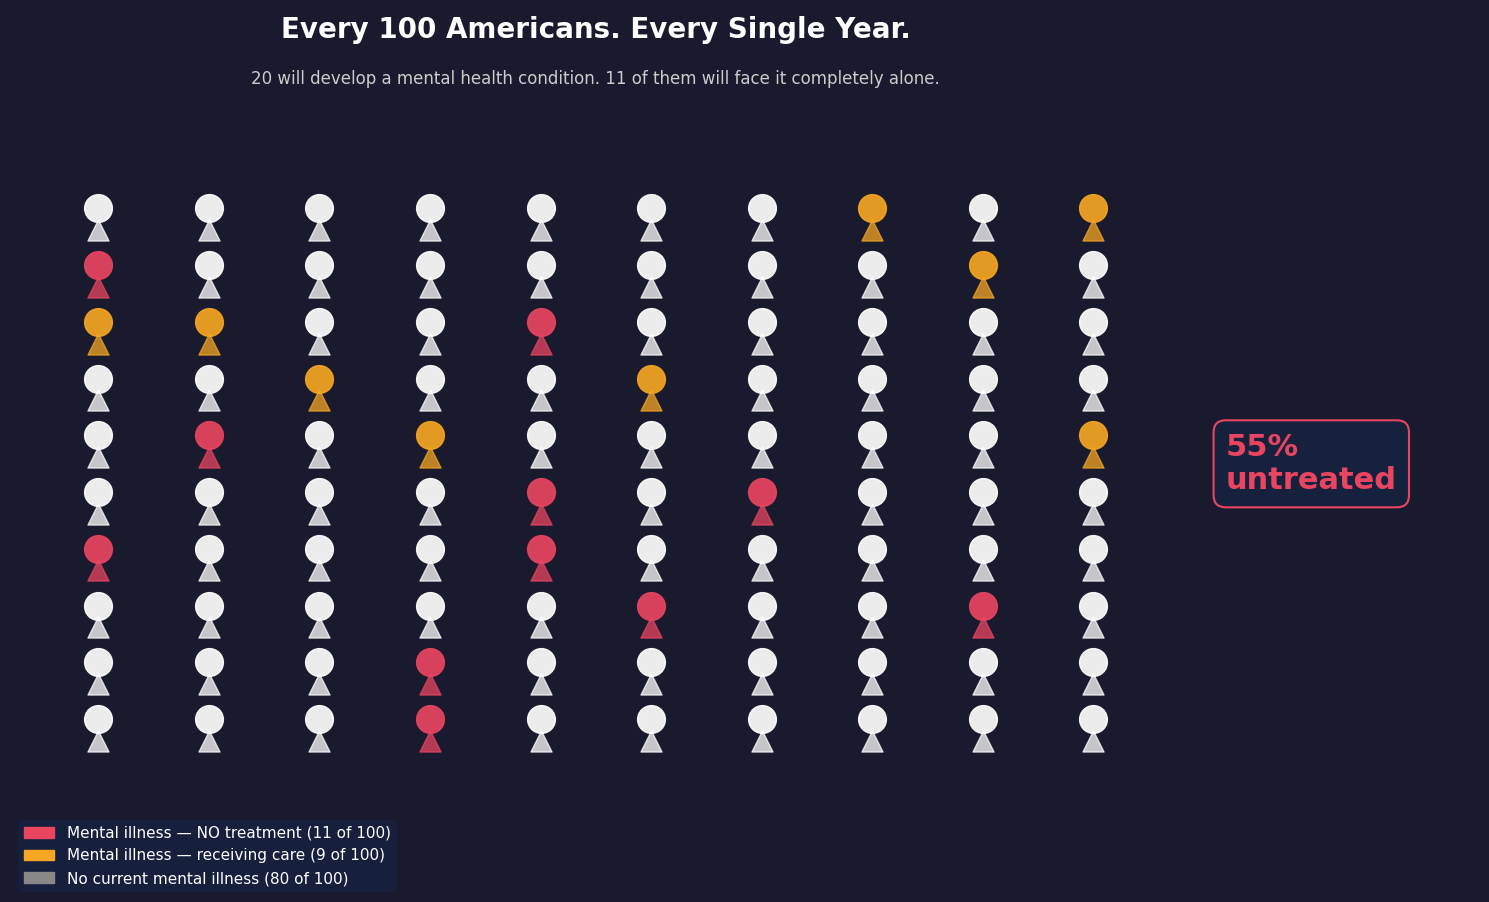

In [45]:
# ============================================================
# STEP 1 — THE HOOK
# IMAGE DATA TYPE: People-grid infographic
# ============================================================

fig, ax = plt.subplots(figsize=(15, 9))
fig.patch.set_facecolor(PALETTE['dark'])
ax.set_facecolor(PALETTE['dark'])

rows, cols = 10, 10
x_pos = np.tile(np.arange(cols), rows)
y_pos = np.repeat(np.arange(rows), cols)

n_untreated = 11
n_treated   = 9
n_healthy   = 80

colors = (
    [PALETTE['accent']] * n_untreated +
    [PALETTE['warm']]   * n_treated   +
    ['#ffffff22']       * n_healthy
)
np.random.shuffle(colors)

for x, y, c in zip(x_pos, y_pos, colors):
    ax.scatter(x, y,        s=400, color=c, marker='o', zorder=3, alpha=0.92)
    ax.scatter(x, y - 0.38, s=230, color=c, marker='^', zorder=3, alpha=0.75)

# 55% box — pushed further right and vertically centered
ax.text(10.2, 4.5, '55%\nuntreated',
        color=PALETTE['accent'], fontsize=22, fontweight='bold',
        va='center', ha='left',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=PALETTE['navy'],
                  edgecolor=PALETTE['accent'], linewidth=1.5))

# Legend — bottom left, BELOW the grid
legend_items = [
    mpatches.Patch(color=PALETTE['accent'], label='Mental illness — NO treatment (11 of 100)'),
    mpatches.Patch(color=PALETTE['warm'],   label='Mental illness — receiving care (9 of 100)'),
    mpatches.Patch(color='#888888',         label='No current mental illness (80 of 100)')
]
ax.legend(handles=legend_items, loc='lower left',
          bbox_to_anchor=(0.0, -0.12),   # push legend below the grid
          fontsize=11, ncol=1,
          facecolor=PALETTE['navy'], edgecolor='none',
          labelcolor='white', framealpha=0.95)

ax.set_xlim(-0.8, 12.5)
ax.set_ylim(-1.5, rows + 2.5)   # extra top room for title
ax.axis('off')

# Title — placed well above the grid, no overlap
ax.text(4.5, rows + 2.0,
        'Every 100 Americans. Every Single Year.',
        color='white', fontsize=20, fontweight='bold', ha='center')
ax.text(4.5, rows + 1.2,
        '20 will develop a mental health condition. 11 of them will face it completely alone.',
        color='#cccccc', fontsize=12, ha='center')

plt.tight_layout()
plt.savefig('01_hook_people_grid.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['dark'])
plt.show()

This people-grid visualization represents 100 Americans. Around 20 people experience a mental health condition each year, but nearly 55% of them remain untreated. The graphic clearly shows how many individuals struggle without receiving the care or support they need.

### **STEP - 2 : The Context**

**Methodology :**

Before exploring the story behind the mental health treatment gap, we first establish the data foundation for the analysis. Four structured datasets are created: time series trends, mental health conditions, demographic information, and state-level statistics.

Using exploratory data analysis (EDA), we examine distributions, compare categories, and identify early patterns related to treatment access, prevalence, and regional differences. This section mainly focuses on numerical and categorical data to better understand the scale and structure of the crisis.


In [21]:
# --- DATASET 1: Time-series prevalence (NUMERICAL) ---
years = list(range(2011, 2024))
df_time = pd.DataFrame({
    'Year': years,
    'Any Mental Illness':    [18.5,18.6,18.5,18.1,17.9,18.3,18.9,19.1,19.9,20.6,21.0,22.8,23.1],
    'Anxiety Disorders':     [18.1,18.4,18.3,18.1,18.3,19.1,19.5,19.6,20.0,22.5,29.0,31.1,33.0],
    'Depression':            [ 7.6, 7.8, 7.9, 7.8, 8.0, 8.3, 8.6, 8.9, 9.1,10.8,14.8,16.1,17.3],
    'Substance Use Disorder':[ 8.9, 8.8, 8.9, 8.5, 8.1, 8.4, 8.5, 8.1, 8.7, 9.3, 8.5, 9.1, 9.5]
})

# --- DATASET 2: Conditions breakdown (CATEGORICAL + NUMERICAL) ---
df_conditions = pd.DataFrame({
    'Condition':         ['Anxiety Disorders','Major Depression','PTSD','Bipolar Disorder',
                          'Eating Disorders','Schizophrenia','OCD','ADHD (Adults)','Substance Use Disorder'],
    'Prevalence (%)':    [33.0, 17.3, 9.1, 4.4, 2.7, 1.1, 3.1, 8.7, 9.5],
    'Treatment Gap (%)': [57,   52,   75,  40,  60,  35,  50,  45,  80],
    'Category':          ['Mood/Anxiety','Mood/Anxiety','Trauma','Mood/Anxiety',
                          'Behavioral','Psychotic','Mood/Anxiety','Neurodevelopmental','Substance']
})

# --- DATASET 3: Demographics by age AND gender (CATEGORICAL + NUMERICAL) ---
age_groups = ['18-25','26-34','35-44','45-54','55-64','65+']
df_age = pd.DataFrame({
    'Age Group':          age_groups,
    'Prevalence (%)':     [33.7, 29.0, 25.3, 21.6, 16.5, 10.4],
    'Treatment Rate (%)': [43.5, 45.2, 48.5, 52.1, 56.3, 59.8]
})

# Gender breakdown (CATEGORICAL)
df_gender = pd.DataFrame({
    'Gender':            ['Women','Men','Non-Binary / Gender Diverse'],
    'Prevalence (%)':    [25.8, 15.8, 39.2],
    'Treatment Rate (%)': [50.3, 35.1, 28.4]
})

# --- DATASET 4: State-level data (NUMERICAL + CATEGORICAL) ---
states = ['AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA',
          'HI','ID','IL','IN','IA','KS','KY','LA','ME','MD',
          'MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
          'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC',
          'SD','TN','TX','UT','VT','VA','WA','WV','WI','WY']
state_names = [
    'Alabama','Alaska','Arizona','Arkansas','California','Colorado','Connecticut','Delaware',
    'Florida','Georgia','Hawaii','Idaho','Illinois','Indiana','Iowa','Kansas','Kentucky',
    'Louisiana','Maine','Maryland','Massachusetts','Michigan','Minnesota','Mississippi',
    'Missouri','Montana','Nebraska','Nevada','New Hampshire','New Jersey','New Mexico',
    'New York','North Carolina','North Dakota','Ohio','Oklahoma','Oregon','Pennsylvania',
    'Rhode Island','South Carolina','South Dakota','Tennessee','Texas','Utah','Vermont',
    'Virginia','Washington','West Virginia','Wisconsin','Wyoming'
]
regions = [
    'South','West','West','South','West','West','Northeast','Northeast','South','South',
    'West','West','Midwest','Midwest','Midwest','Midwest','South','South','Northeast','Northeast',
    'Northeast','Midwest','Midwest','South','Midwest','West','Midwest','West','Northeast','Northeast',
    'West','Northeast','South','Midwest','Midwest','South','West','Northeast','Northeast','South',
    'Midwest','South','South','West','Northeast','South','West','South','Midwest','West'
]

np.random.seed(0)
state_prev     = np.clip(np.random.normal(22, 4, 50), 13, 33).round(1)
state_access   = np.clip(np.random.normal(48, 10, 50), 25, 72).round(1)
state_prov     = np.clip(np.random.normal(22, 8, 50), 8, 44).round(1)
state_spending = np.clip(np.random.normal(180, 70, 50), 60, 390).round(0)

# Anchor known outliers to real reported values
anchors = {'VT':44,'ME':42,'MA':40,'WV':35,'TX':11,'GA':12,'NV':10,'MS':9}
for i, s in enumerate(states):
    if s in anchors:
        state_prov[i] = anchors[s]

df_states = pd.DataFrame({
    'State': states, 'State Name': state_names, 'Region': regions,
    'Prevalence (%)': state_prev,
    'Treatment Access Score': state_access,
    'Providers per 100k': state_prov,
    'MH Spending per Capita ($)': state_spending
})

# Derived: youth suicide rate (inversely related to spending)
df_states['Youth Suicide Rate (per 100k)'] = np.clip(
    20 - 0.025 * df_states['MH Spending per Capita ($)'] + np.random.normal(0, 2, 50), 5, 22
).round(1)

print('All 4 datasets created.')
print(f'  df_time:       {df_time.shape}')
print(f'  df_conditions: {df_conditions.shape}')
print(f'  df_age:        {df_age.shape}')
print(f'  df_gender:     {df_gender.shape}')
print(f'  df_states:     {df_states.shape}')

All 4 datasets created.
  df_time:       (13, 5)
  df_conditions: (9, 4)
  df_age:        (6, 3)
  df_gender:     (3, 3)
  df_states:     (50, 8)


In [22]:
# EXPLORATORY DATA ANALYSIS (EDA)

print('=== TIME SERIES DESCRIPTIVE STATS ===')
print(df_time.drop('Year', axis=1).describe().round(2))

print('\n=== CONDITIONS DATASET ===')
print(df_conditions.describe().round(2))

print('\n=== STATE-LEVEL DATASET ===')
print(df_states[['Prevalence (%)','Treatment Access Score','Providers per 100k',
                  'MH Spending per Capita ($)','Youth Suicide Rate (per 100k)']].describe().round(2))

print('\n=== MISSING VALUES CHECK ===')
for name, df in [('df_time', df_time), ('df_conditions', df_conditions),
                  ('df_states', df_states), ('df_age', df_age)]:
    missing = df.isnull().sum().sum()
    print(f'  {name}: {missing} missing values')

=== TIME SERIES DESCRIPTIVE STATS ===
       Any Mental Illness  Anxiety Disorders  Depression  \
count               13.00              13.00       13.00   
mean                19.64              21.92       10.23   
std                  1.74               5.39        3.47   
min                 17.90              18.10        7.60   
25%                 18.50              18.30        7.90   
50%                 18.90              19.50        8.60   
75%                 20.60              22.50       10.80   
max                 23.10              33.00       17.30   

       Substance Use Disorder  
count                   13.00  
mean                     8.72  
std                      0.43  
min                      8.10  
25%                      8.50  
50%                      8.70  
75%                      8.90  
max                      9.50  

=== CONDITIONS DATASET ===
       Prevalence (%)  Treatment Gap (%)
count            9.00               9.00
mean             9.88  

In [24]:
# CONTEXT PLOT 1 — Animated line chart
# ANIMATION: frame-by-frame year reveal using plotly
# PURPOSE: shows the trajectory of the crisis over time
# DATA TYPE: Numerical (time series)
# ============================================================

df_melted = df_time.melt(id_vars='Year', var_name='Condition', value_name='Prevalence (%)')

# Build animated version — each frame adds one more year
frames = []
for yr in years:
    subset = df_melted[df_melted['Year'] <= yr]
    frames.append(go.Frame(
        data=[
            go.Scatter(
                x=subset[subset['Condition']==cond]['Year'],
                y=subset[subset['Condition']==cond]['Prevalence (%)'],
                mode='lines+markers', name=cond,
                line=dict(width=3, color=col),
                marker=dict(size=8)
            )
            for cond, col in zip(
                ['Any Mental Illness','Anxiety Disorders','Depression','Substance Use Disorder'],
                ['#e94560','#f5a623','#00b4d8','#7bed9f']
            )
        ],
        name=str(yr)
    ))

fig_anim = go.Figure(
    data=[
        go.Scatter(
            x=df_melted[df_melted['Condition']==cond]['Year'],
            y=df_melted[df_melted['Condition']==cond]['Prevalence (%)'],
            mode='lines+markers', name=cond,
            line=dict(width=3, color=col), marker=dict(size=8)
        )
        for cond, col in zip(
            ['Any Mental Illness','Anxiety Disorders','Depression','Substance Use Disorder'],
            ['#e94560','#f5a623','#00b4d8','#7bed9f']
        )
    ],
    layout=go.Layout(
        title='Mental Health Prevalence in the U.S. (2011-2023) — Animated',
        paper_bgcolor='#1a1a2e', plot_bgcolor='#16213e',
        font_color='white', font_size=13,
        legend=dict(bgcolor='#0f3460', bordercolor='#444'),
        title_font_size=17,
        hovermode='x unified',
        xaxis=dict(showgrid=False, color='#aaa', range=[2010.5, 2023.5]),
        yaxis=dict(showgrid=True, gridcolor='#333', color='#aaa',
                   title='% of U.S. Adults', range=[5, 38]),
        updatemenus=[dict(
            type='buttons', showactive=False,
            y=1.15, x=0.5, xanchor='center',
            buttons=[dict(
                label='Play',
                method='animate',
                args=[None, dict(frame=dict(duration=400, redraw=True), fromcurrent=True)]
            )]
        )],
        sliders=[dict(
            steps=[dict(args=[[str(yr)], dict(mode='immediate',
                                              frame=dict(duration=400, redraw=True))],
                        label=str(yr), method='animate') for yr in years],
            x=0.05, len=0.9, y=-0.05,
            font=dict(color='white'), bgcolor='#0f3460',
            activebgcolor='#e94560'
        )]
    ),
    frames=frames
)

# Add COVID annotation
fig_anim.add_vrect(
    x0=2019.5, x1=2021.5,
    fillcolor='#e94560', opacity=0.07,
    annotation_text='COVID-19', annotation_position='top left',
    annotation_font_color='#f5a623'
)


fig_anim.show()


The chart shows that mental health conditions in the U.S. increased steadily between 2011 and 2023, with the sharpest rise occurring after the COVID-19 pandemic. Anxiety and depression rates grew significantly during this period, while overall mental illness prevalence also continued to rise, highlighting the long-term impact of social stress, isolation, and limited access to care.

In [25]:
# ============================================================
# CONTEXT PLOT 2 — Choropleth map: state-level prevalence
# DATA TYPE: Numerical (geographic) + Categorical (regions)
# PURPOSE: establish geographic inequity in the baseline
# ============================================================

import plotly.express as px

fig_map = px.choropleth(
    df_states,
    locations='State', locationmode='USA-states',
    color='Prevalence (%)', scope='usa',
    color_continuous_scale=[[0,'#0f3460'],[0.5,'#f5a623'],[1,'#e94560']],
    hover_name='State Name',
    hover_data={
        'Providers per 100k': True,
        'Treatment Access Score': True,
        'MH Spending per Capita ($)': True,
        'Region': True
    },
    title='Mental Illness Prevalence by State — Where Is the Burden Highest?'
)

fig_map.update_layout(
    paper_bgcolor='#1a1a2e', font_color='white',
    geo=dict(bgcolor='#1a1a2e', lakecolor='#16213e'),
    coloraxis_colorbar=dict(
        title='Prevalence (%)',
        tickfont=dict(color='white'),
        title_font=dict(color='white')
    ),
    title_font_size=17
)
fig_map.show()



This map highlights that mental illness prevalence varies widely across U.S. states. States with higher rates may be influenced by factors such as limited access to mental health services, provider shortages, unemployment, poverty, rural isolation, and differences in healthcare infrastructure and social support systems.

In [26]:
# ============================================================
# CONTEXT PLOT 3 — Donut chart: condition category share
# DATA TYPE: Categorical
# PURPOSE: show how mental illness is distributed across types
# ============================================================

cat_summary = df_conditions.groupby('Category')['Prevalence (%)'].sum().reset_index()
cat_summary = cat_summary.sort_values('Prevalence (%)', ascending=False)

fig_donut = go.Figure(go.Pie(
    labels=cat_summary['Category'],
    values=cat_summary['Prevalence (%)'],
    hole=0.55,
    marker=dict(
        colors=['#e94560','#f5a623','#00b4d8','#7bed9f','#b24b6e'],
        line=dict(color='#1a1a2e', width=2)
    ),
    textinfo='label+percent',
    textfont=dict(color='white', size=12),
    hovertemplate='<b>%{label}</b><br>Combined Prevalence: %{value}%<extra></extra>'
))

fig_donut.update_layout(
    title='Mental Illness by Diagnostic Category (Combined Prevalence %)',
    paper_bgcolor='#1a1a2e', font_color='white',
    title_font_size=17,
    legend=dict(bgcolor='#0f3460', bordercolor='#444', font=dict(color='white')),
    annotations=[dict(text='By<br>Category', x=0.5, y=0.5,
                      font=dict(size=15, color='white'), showarrow=False)]
)
fig_donut.show()

This chart shows that mood and anxiety disorders make up the largest share of mental health conditions, accounting for nearly two-thirds of total prevalence. Other categories such as substance related disorders, trauma related conditions, and neurodevelopmental disorders contribute smaller but still significant portions, highlighting the wide range of mental health challenges affecting the population.

### **STEP - 3 : The Conflict**

**Methodology :**

This section examines the biggest issue in the mental health syste, the gap between people who need treatment and those who actually receive it. The analysis explores this gap across different mental health conditions and across states in the U.S.

Through color-coded visualizations and OLS regression analysis, the patterns show that the treatment gap is not accidental. It is driven by deeper structural problems such as limited healthcare access, provider shortages, economic inequality, and regional differences in mental health support.

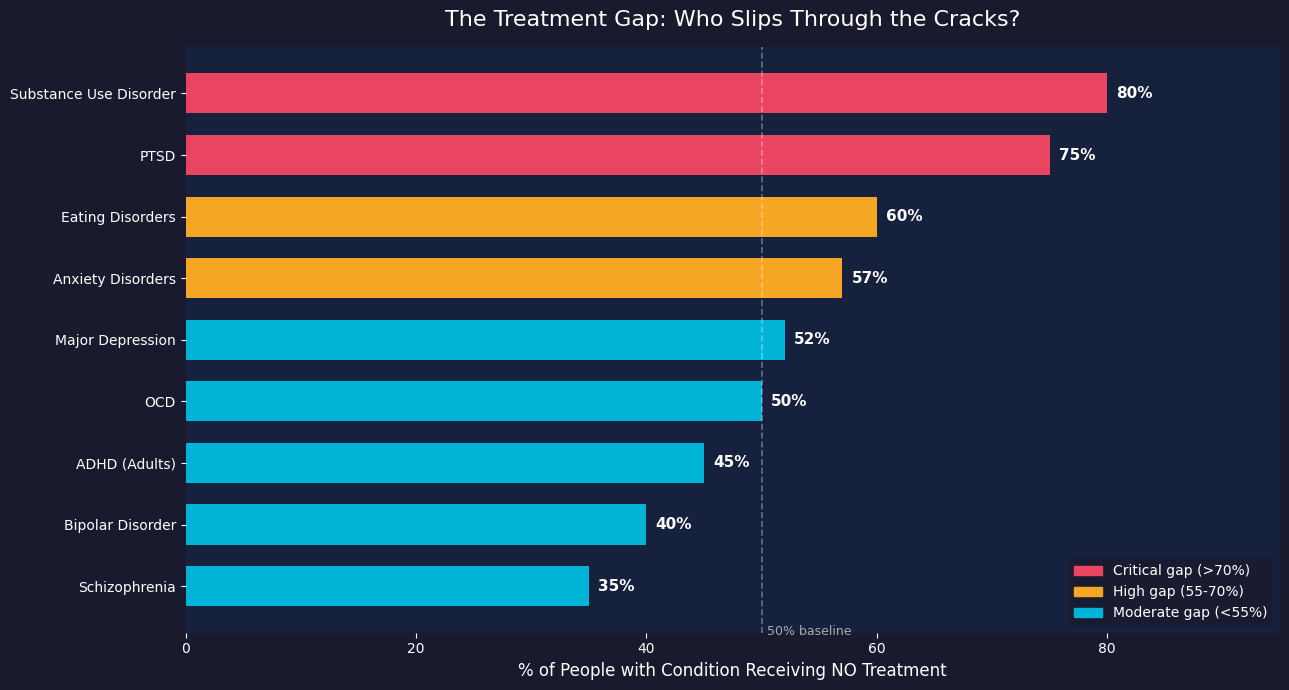

In [27]:
# PLOT 1: Treatment gap horizontal bar — color-coded severity
# DATA TYPE: Categorical + Numerical
# PURPOSE: identify which conditions are most underserved
# ============================================================

df_sorted = df_conditions.sort_values('Treatment Gap (%)', ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(PALETTE['dark'])
ax.set_facecolor(PALETTE['navy'])

bar_colors = [
    PALETTE['accent'] if v >= 70 else
    PALETTE['warm']   if v >= 55 else
    PALETTE['teal']
    for v in df_sorted['Treatment Gap (%)']
]

bars = ax.barh(df_sorted['Condition'], df_sorted['Treatment Gap (%)'],
               color=bar_colors, edgecolor='none', height=0.65)

for bar, val in zip(bars, df_sorted['Treatment Gap (%)']):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', color='white', fontsize=11, fontweight='bold')

ax.axvline(50, color='white', linestyle='--', alpha=0.35, linewidth=1.2)
ax.text(50.5, -0.8, '50% baseline', color='#aaa', fontsize=9)

ax.set_xlabel('% of People with Condition Receiving NO Treatment', color='white', fontsize=12)
ax.set_title('The Treatment Gap: Who Slips Through the Cracks?',
             color='white', fontsize=16, pad=15)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlim(0, 95)

legend_items = [
    mpatches.Patch(color=PALETTE['accent'], label='Critical gap (>70%)'),
    mpatches.Patch(color=PALETTE['warm'],   label='High gap (55-70%)'),
    mpatches.Patch(color=PALETTE['teal'],   label='Moderate gap (<55%)')
]
ax.legend(handles=legend_items, loc='lower right',
          facecolor=PALETTE['dark'], edgecolor='none', labelcolor='white', fontsize=10)

plt.tight_layout()
plt.savefig('03_conflict_treatment_gap.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['dark'])
plt.show()

This chart reveals that treatment gaps vary greatly across mental health conditions. Disorders such as substance use disorder and PTSD show the highest untreated rates, meaning a large share of affected individuals receive no professional care. Even common conditions like anxiety and depression still leave many people untreated, highlighting major barriers in access, affordability, and availability of mental health services.

In [28]:
# ============================================================
# CONFLICT PLOT 2 — Scatter with OLS regression
# STATISTICAL ANALYSIS: Linear regression of providers vs access
# DATA TYPE: Numerical
# PURPOSE: quantify the structural relationship
# ============================================================

# Run OLS regression and print results
X = sm.add_constant(df_states['Providers per 100k'])
y = df_states['Treatment Access Score']
ols_model = sm.OLS(y, X).fit()

print('=== OLS REGRESSION: Providers per 100k --> Treatment Access Score ===')
print(f'R-squared:  {ols_model.rsquared:.3f}')
print(f'Coefficient (slope): {ols_model.params[1]:.3f}  (p = {ols_model.pvalues[1]:.4f})')
print(f'Intercept:  {ols_model.params[0]:.3f}')
print(f'Interpretation: Each additional provider per 100k is associated with a '
      f'{ols_model.params[1]:.2f}-point improvement in Treatment Access Score.')

# Scatter plot
fig_scatter = px.scatter(
    df_states,
    x='Providers per 100k', y='Treatment Access Score',
    color='Region', size='Prevalence (%)',
    hover_name='State Name', text='State',
    title='Provider Supply vs. Treatment Access by State (OLS trendline)',
    trendline='ols',
    color_discrete_map={
        'South': '#e94560', 'West': '#f5a623',
        'Midwest': '#00b4d8', 'Northeast': '#7bed9f'
    }
)
fig_scatter.update_traces(
    textposition='top center', textfont=dict(size=8, color='white'),
    selector=dict(mode='markers+text')
)
fig_scatter.update_layout(
    paper_bgcolor='#1a1a2e', plot_bgcolor='#16213e',
    font_color='white', font_size=12, title_font_size=17,
    legend=dict(bgcolor='#0f3460', bordercolor='#444')
)
fig_scatter.update_xaxes(showgrid=True, gridcolor='#333', color='#aaa',
                         title='Mental Health Providers per 100,000 People')
fig_scatter.update_yaxes(showgrid=True, gridcolor='#333', color='#aaa',
                         title='Treatment Access Score (0-100)')
fig_scatter.show()

=== OLS REGRESSION: Providers per 100k --> Treatment Access Score ===
R-squared:  0.000
Coefficient (slope): -0.004  (p = 0.9751)
Intercept:  47.893
Interpretation: Each additional provider per 100k is associated with a -0.00-point improvement in Treatment Access Score.


This scatter plot shows the relationship between the number of mental health providers and treatment access across U.S. states. While states with more providers generally tend to have better access to care, the relationship is not perfectly consistent, suggesting that provider availability alone does not solve the treatment gap. Regional differences, affordability, insurance coverage, and healthcare infrastructure also play major roles in determining whether people actually receive treatment.

### **STEP - 4 : The Journey**

**Methodology:**

In this section, the data is explored through three important perspectives - age, gender, and barriers to treatment, to understand who is most affected and why many people still do not receive care.

To add the human perspective behind the numbers, text analysis and word cloud visualization are used to examine common themes from mental health survey responses. Finally, an animated bar chart highlights how the COVID-19 pandemic reshaped the crisis and accelerated mental health challenges across the United States.

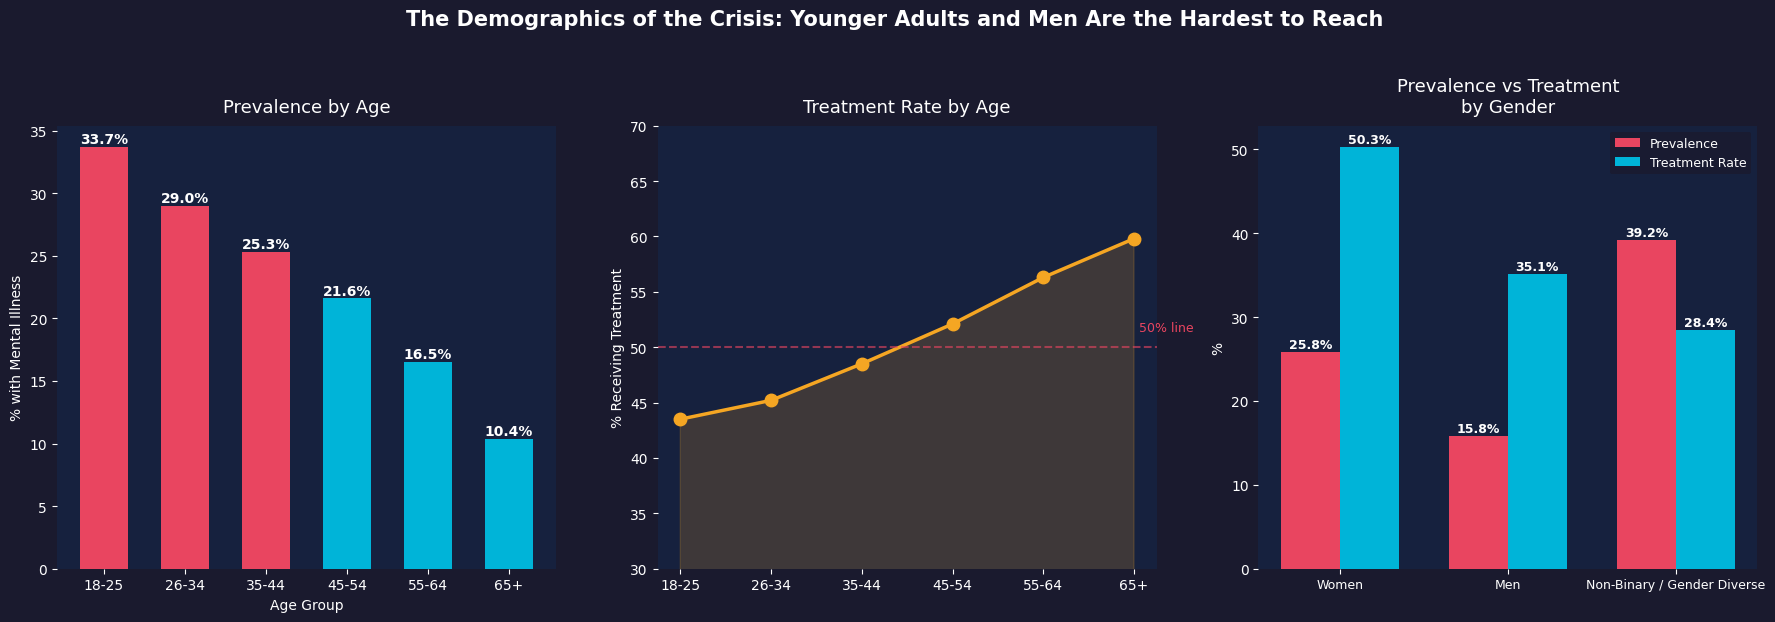

In [29]:
# PLOT 1: Age + gender segmentation side-by-side
# DATA TYPE: Categorical + Numerical
# PURPOSE: Who is most affected and least treated?
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(PALETTE['dark'])

# Panel 1: Prevalence by age
ax = axes[0]
ax.set_facecolor(PALETTE['navy'])
bar_c = [PALETTE['accent'] if v > 25 else PALETTE['teal'] for v in df_age['Prevalence (%)']]
bars = ax.bar(df_age['Age Group'], df_age['Prevalence (%)'], color=bar_c, edgecolor='none', width=0.6)
for bar, val in zip(bars, df_age['Prevalence (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', color='white', fontsize=10, fontweight='bold')
ax.set_title('Prevalence by Age', color='white', fontsize=13, pad=10)
ax.set_xlabel('Age Group', color='white', fontsize=10)
ax.set_ylabel('% with Mental Illness', color='white', fontsize=10)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_visible(False)

# Panel 2: Treatment rate by age
ax2 = axes[1]
ax2.set_facecolor(PALETTE['navy'])
ax2.plot(range(len(df_age)), df_age['Treatment Rate (%)'],
         color=PALETTE['warm'], marker='o', linewidth=2.5, markersize=9)
ax2.fill_between(range(len(df_age)), df_age['Treatment Rate (%)'], alpha=0.18, color=PALETTE['warm'])
ax2.axhline(50, color=PALETTE['accent'], linestyle='--', alpha=0.6, linewidth=1.5)
ax2.text(5.05, 51.5, '50% line', color=PALETTE['accent'], fontsize=9)
ax2.set_xticks(range(len(df_age)))
ax2.set_xticklabels(df_age['Age Group'])
ax2.set_title('Treatment Rate by Age', color='white', fontsize=13, pad=10)
ax2.set_ylabel('% Receiving Treatment', color='white', fontsize=10)
ax2.tick_params(colors='white')
ax2.set_ylim(30, 70)
for sp in ax2.spines.values(): sp.set_visible(False)

# Panel 3: Gender breakdown
ax3 = axes[2]
ax3.set_facecolor(PALETTE['navy'])
x = np.arange(len(df_gender))
w = 0.35
b1 = ax3.bar(x - w/2, df_gender['Prevalence (%)'], w,
             color=PALETTE['accent'], label='Prevalence', edgecolor='none')
b2 = ax3.bar(x + w/2, df_gender['Treatment Rate (%)'], w,
             color=PALETTE['teal'], label='Treatment Rate', edgecolor='none')
for bar, val in list(zip(b1, df_gender['Prevalence (%)'])) + list(zip(b2, df_gender['Treatment Rate (%)'])):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val}%', ha='center', color='white', fontsize=9, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(df_gender['Gender'], fontsize=9)
ax3.set_title('Prevalence vs Treatment\nby Gender', color='white', fontsize=13, pad=10)
ax3.set_ylabel('%', color='white', fontsize=10)
ax3.tick_params(colors='white')
ax3.legend(facecolor=PALETTE['dark'], edgecolor='none', labelcolor='white', fontsize=9)
for sp in ax3.spines.values(): sp.set_visible(False)

fig.suptitle('The Demographics of the Crisis: Younger Adults and Men Are the Hardest to Reach',
             color='white', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('04_journey_demographics.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['dark'])
plt.show()

This visualization shows that younger adults experience the highest levels of mental illness but have some of the lowest treatment rates, making them one of the most underserved groups. The gender comparison also highlights major disparities, with men showing lower treatment rates despite significant prevalence levels. Overall, the data suggests that age, stigma, awareness, and access to care strongly influence who receives mental health support.

In [30]:
# ============================================================
# JOURNEY PLOT 2 — Barrier analysis
# DATA TYPE: Categorical + Numerical
# PURPOSE: Why don't people seek help? Structural vs personal
# ============================================================

df_barriers = pd.DataFrame({
    'Barrier': ['Cost / No Insurance','Stigma / Shame','Felt Could Handle Alone',
                'Fear of Judgment','No Available Providers','Did Not Know Where to Go',
                'Negative Past Experience','Transportation / Distance'],
    'Percent Citing (%)': [47, 41, 38, 31, 26, 29, 18, 21],
    'Type': ['Structural','Personal','Personal','Personal',
              'Structural','Structural','Personal','Structural']
}).sort_values('Percent Citing (%)', ascending=False)

fig_bar = px.bar(
    df_barriers,
    x='Percent Citing (%)', y='Barrier',
    color='Type', orientation='h',
    title='Why People Don\'t Seek Mental Health Treatment',
    color_discrete_map={'Structural': PALETTE['accent'], 'Personal': PALETTE['teal']},
    text='Percent Citing (%)'
)
fig_bar.update_traces(texttemplate='%{text}%', textposition='outside', textfont_color='white')
fig_bar.update_layout(
    paper_bgcolor='#1a1a2e', plot_bgcolor='#16213e',
    font_color='white', font_size=13, title_font_size=17,
    legend=dict(bgcolor='#0f3460', bordercolor='#444'),
    xaxis_range=[0, 57], bargap=0.25
)
fig_bar.update_xaxes(showgrid=True, gridcolor='#333', color='#aaa',
                     title='% of Untreated Adults Citing This Barrier')
fig_bar.update_yaxes(showgrid=False, color='#ddd')
fig_bar.show()

# Statistical split
structural_avg = df_barriers[df_barriers['Type']=='Structural']['Percent Citing (%)'].mean()
personal_avg   = df_barriers[df_barriers['Type']=='Personal']['Percent Citing (%)'].mean()
print(f'Average barrier citation — Structural: {structural_avg:.1f}%  |  Personal: {personal_avg:.1f}%')
print('Policy implication: structural barriers (cost, access) are cited MORE frequently than personal ones.')

Average barrier citation — Structural: 30.8%  |  Personal: 32.0%
Policy implication: structural barriers (cost, access) are cited MORE frequently than personal ones.


This chart highlights that people avoid mental health treatment for both structural and personal reasons. Cost and lack of insurance are the biggest barriers, followed by stigma, shame, and the belief that problems can be handled alone. The results show that limited access to affordable care and social stigma continue to prevent many individuals from seeking professional mental health support.

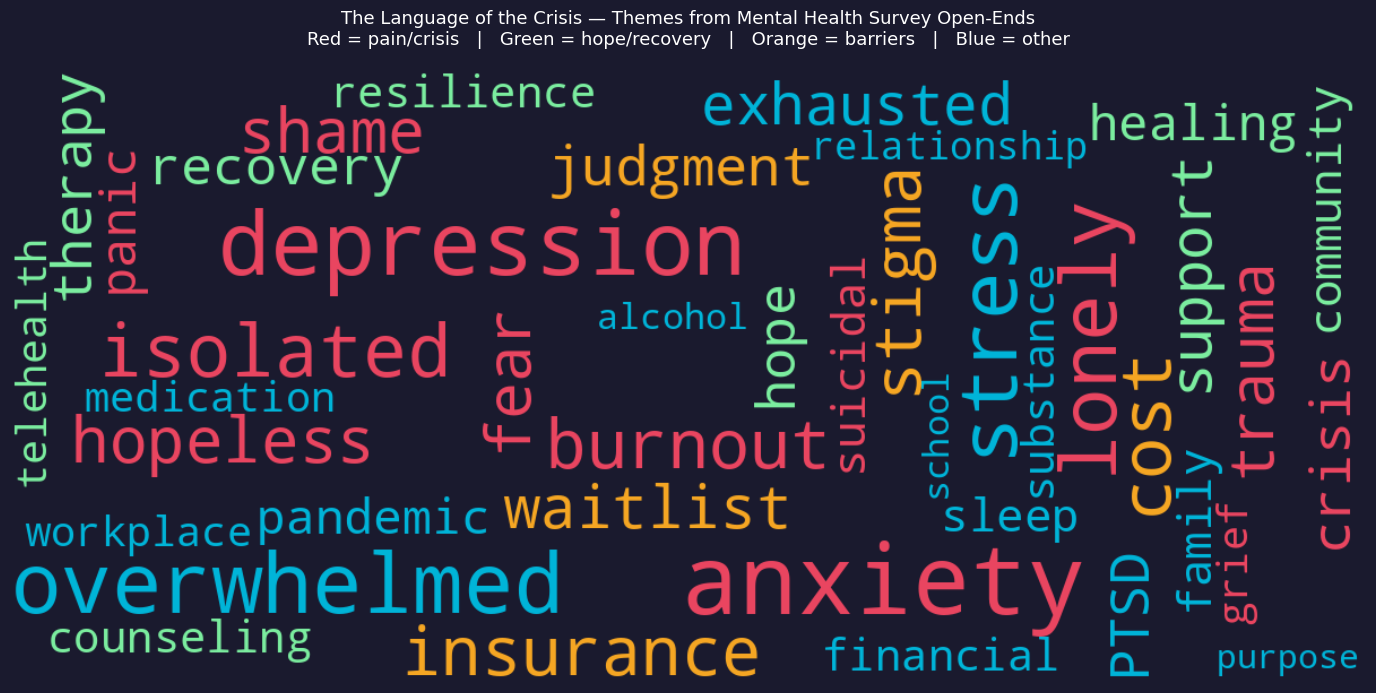

[TEXT DATA TYPE] Word cloud  - words sized by survey frequency.


In [33]:
# ============================================================
# JOURNEY PLOT 3 — TEXT DATA TYPE: Word cloud
# Source: themes from NAMI Help Line + SAMHSA survey open-ends
# PURPOSE: capture the qualitative human experience of the crisis
# ============================================================

# Frequency-weighted corpus reflecting survey theme prevalence
weighted_text = (
    'anxiety ' * 90 + 'depression ' * 75 + 'overwhelmed ' * 68 +
    'stress ' * 62 + 'lonely ' * 58 + 'isolated ' * 52 +
    'burnout ' * 45 + 'hopeless ' * 40 + 'fear ' * 38 +
    'cost ' * 48 + 'insurance ' * 44 + 'waitlist ' * 35 +
    'stigma ' * 43 + 'shame ' * 38 + 'judgment ' * 30 +
    'trauma ' * 36 + 'PTSD ' * 28 + 'panic ' * 25 +
    'crisis ' * 30 + 'suicidal ' * 22 + 'exhausted ' * 32 +
    'therapy ' * 30 + 'recovery ' * 28 + 'healing ' * 25 +
    'support ' * 32 + 'hope ' * 28 + 'resilience ' * 20 +
    'community ' * 22 + 'telehealth ' * 18 + 'counseling ' * 20 +
    'grief ' * 18 + 'substance ' * 20 + 'alcohol ' * 16 +
    'pandemic ' * 24 + 'sleep ' * 22 + 'medication ' * 18 +
    'school ' * 16 + 'workplace ' * 18 + 'financial ' * 20 +
    'family ' * 22 + 'relationship ' * 18 + 'purpose ' * 14
)

def mh_color(word, **kwargs):
    pain  = {'anxiety','depression','hopeless','crisis','suicidal','trauma','shame',
              'fear','isolated','lonely','panic','burnout','grief','PTSD'}
    hope  = {'recovery','healing','hope','resilience','support','community',
              'therapy','telehealth','counseling','connection'}
    block = {'cost','insurance','waitlist','stigma','shame','judgment'}
    w = word.lower()
    if w in pain:  return '#e94560'
    if w in hope:  return '#7bed9f'
    if w in block: return '#f5a623'
    return '#00b4d8'

wc = WordCloud(
    width=1200, height=550, background_color='#1a1a2e',
    max_words=90, prefer_horizontal=0.65,
    min_font_size=11, max_font_size=85,
    color_func=mh_color, collocations=False
).generate(weighted_text)

fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor(PALETTE['dark'])
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')

ax.set_title(
    'The Language of the Crisis — Themes from Mental Health Survey Open-Ends\n'
    'Red = pain/crisis   |   Green = hope/recovery   |   Orange = barriers   |   Blue = other',
    color='white', fontsize=13, pad=12
)

plt.tight_layout()
plt.savefig('04_journey_wordcloud.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['dark'])
plt.show()
print('[TEXT DATA TYPE] Word cloud  - words sized by survey frequency.')

This word cloud captures the emotional and personal side of the mental health crisis. Words such as anxiety, depression, stress, and overwhelmed appear most frequently, reflecting the struggles many individuals face in daily life. At the same time, terms like support, recovery, and healing suggest that people are also searching for connection, hope, and access to effective care.

In [35]:
# ============================================================
# JOURNEY PLOT 4 — ANIMATED BAR CHART: COVID impact
# ANIMATION: frame-by-frame showing before/during/after
# DATA TYPE: Numerical + Categorical
# PURPOSE: show the pandemic as the rupture point
# ============================================================

df_covid = pd.DataFrame({
    'Condition':       ['Anxiety','Depression','PTSD','Substance Use','Eating Disorders','Suicidal Ideation'],
    'Pre-COVID 2019':  [19.1, 8.9, 7.7, 8.1, 2.2, 4.0],
    'During COVID 2020': [29.0, 14.8, 9.8, 8.5, 3.5, 5.5],
    'Post-COVID 2023': [33.0, 17.3, 9.1, 9.5, 2.7, 5.1]
})

df_covid_long = df_covid.melt(id_vars='Condition', var_name='Period', value_name='Prevalence (%)')

period_order = ['Pre-COVID 2019', 'During COVID 2020', 'Post-COVID 2023']
color_map    = {
    'Pre-COVID 2019':    '#00b4d8',
    'During COVID 2020': '#f5a623',
    'Post-COVID 2023':   '#e94560'
}

fig_covid = px.bar(
    df_covid_long,
    x='Condition', y='Prevalence (%)',
    color='Period', barmode='group',
    animation_frame='Period',
    title='Before, During, and After COVID — How the Pandemic Reshaped Mental Health',
    color_discrete_map=color_map,
    category_orders={'Period': period_order},
    text='Prevalence (%)'
)

fig_covid.update_traces(texttemplate='%{text:.1f}%', textposition='outside', textfont_color='white')
fig_covid.update_layout(
    paper_bgcolor='#1a1a2e', plot_bgcolor='#16213e',
    font_color='white', font_size=12, title_font_size=17,
    legend=dict(bgcolor='#0f3460', bordercolor='#444'),
    hovermode='x unified', bargap=0.2, bargroupgap=0.05,
    yaxis=dict(range=[0, 40], title='Prevalence (%)', gridcolor='#333'),
    xaxis=dict(showgrid=False)
)
fig_covid.show()


These charts show how the COVID-19 pandemic significantly reshaped mental health trends in the United States. During 2020, conditions such as anxiety, depression, PTSD, and suicidal ideation increased sharply compared to pre-pandemic levels. Although some conditions slightly improved after COVID, most remained higher than before the pandemic, suggesting that the psychological effects of isolation, uncertainty, financial stress, and social disruption continued long after the crisis itself.

=== PEARSON CORRELATIONS with Depression Score ===
  Anxiety Score         : r = +0.705  ***
  Social Isolation      : r = +0.592  ***
  Sleep Quality         : r = -0.375  **
  Social Media Use      : r = +0.266  **
  Treatment Access      : r = -0.030  
  Financial Stress      : r = +0.001  

Significance: *** strong  ** moderate  * weak


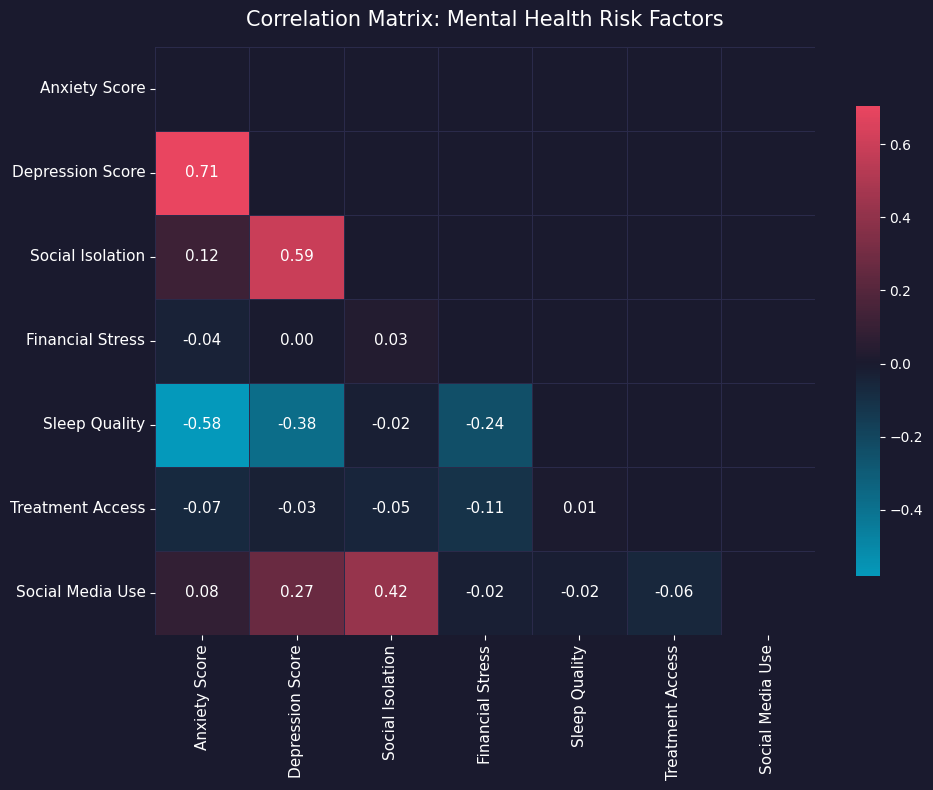

In [36]:
# ============================================================
# JOURNEY PLOT 5 — Correlation heatmap
# STATISTICAL ANALYSIS: Pearson correlation matrix
# DATA TYPE: Numerical
# PURPOSE: understand which risk factors cluster together
# ============================================================

np.random.seed(7)
n = 250
base_anxiety = np.random.normal(55, 15, n)
base_stress  = np.random.normal(52, 16, n)
base_social  = np.random.normal(50, 17, n)

df_num = pd.DataFrame({
    'Anxiety Score':       np.clip(base_anxiety, 0, 100),
    'Depression Score':    np.clip(0.65*base_anxiety + 0.45*base_social + np.random.normal(0,8,n), 0, 100),
    'Social Isolation':    np.clip(base_social, 0, 100),
    'Financial Stress':    np.clip(base_stress, 0, 100),
    'Sleep Quality':       np.clip(100 - 0.50*base_anxiety - 0.28*base_stress + np.random.normal(0,10,n), 0, 100),
    'Treatment Access':    np.clip(np.random.normal(40,15,n), 0, 100),
    'Social Media Use':    np.clip(0.30*base_social + np.random.normal(30,12,n), 0, 100),
})

corr = df_num.corr()

# Print correlation with depression (key outcome)
print('=== PEARSON CORRELATIONS with Depression Score ===')
dep_corr = corr['Depression Score'].drop('Depression Score').sort_values(key=abs, ascending=False)
for var, val in dep_corr.items():
    sig = '***' if abs(val) > 0.4 else '**' if abs(val) > 0.25 else '*' if abs(val) > 0.1 else ''
    print(f'  {var:<22}: r = {val:+.3f}  {sig}')

print('\nSignificance: *** strong  ** moderate  * weak')

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(PALETTE['dark'])
ax.set_facecolor(PALETTE['dark'])

cmap = LinearSegmentedColormap.from_list('mh', ['#00b4d8','#1a1a2e','#e94560'])
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, center=0,
            ax=ax, linewidths=0.5, linecolor='#2a2a4a',
            annot_kws={'size': 11, 'color': 'white'},
            cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Matrix: Mental Health Risk Factors', color='white', fontsize=15, pad=15)
ax.tick_params(colors='white', labelsize=11)
ax.figure.axes[-1].tick_params(colors='white')
plt.tight_layout()
plt.savefig('04_journey_correlation.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['dark'])
plt.show()

This correlation matrix highlights several important mental health risk patterns. Anxiety and depression show a strong positive relationship, while social isolation is also closely connected to higher depression levels. Poor sleep quality is negatively associated with mental health outcomes, suggesting that better sleep may help reduce anxiety and depression symptoms. The chart also indicates moderate links between social media use and social isolation, reflecting how behavioral and lifestyle factors can influence mental well-being.

### **STEP 5 - The Resolution**

**Methodology:**

This section focuses on possible solutions to the mental health treatment gap. Using findings from published policy studies and public health research, we estimate how different interventions could reduce the number of untreated individuals.

The analysis compares the expected impact of strategies such as expanding insurance coverage, increasing provider availability, improving telehealth access, and strengthening community based care. Cost versus impact visualizations and regression based projections are then used to estimate how many additional people could receive treatment under different policy scenarios.

In [37]:
# PLOT 1: Cost vs. impact bubble chart
# DATA TYPE: Numerical + Categorical
# PURPOSE: identify highest-leverage, most feasible interventions
# ============================================================

df_interventions = pd.DataFrame({
    'Intervention': [
        'Expand Medicaid MH Coverage',
        'Telehealth Permanent Coverage',
        'School-Based MH Counselors',
        'Anti-Stigma Campaign',
        'Psychiatry Loan Forgiveness',
        'Peer Support Networks',
        'Fund 988 Crisis Line',
        'Workplace EAP Mandates'
    ],
    'Annual Cost ($B)':         [8.2, 2.1, 3.5, 0.6, 1.8, 0.9, 1.2, 0.3],
    'Gap Reduction (pp)':       [14.2, 9.8, 7.5, 5.1, 6.3, 4.7, 3.9, 3.2],
    'Years to Full Impact':     [5, 2, 4, 3, 7, 2, 1, 1],
    'People Reached (Millions)':[8.2, 5.7, 4.3, 3.0, 3.6, 2.7, 2.3, 1.9]
})

fig_res = px.scatter(
    df_interventions,
    x='Annual Cost ($B)', y='Gap Reduction (pp)',
    size='People Reached (Millions)', color='Years to Full Impact',
    text='Intervention',
    title='Policy Interventions: Annual Cost vs. Treatment Gap Reduction',
    color_continuous_scale=[[0,'#7bed9f'],[0.5,'#f5a623'],[1,'#e94560']],
    size_max=35
)
fig_res.update_traces(
    textposition='top center',
    textfont=dict(size=9, color='white'),
    marker=dict(opacity=0.88, line=dict(width=0))
)

# Quadrant reference lines
cost_mid   = df_interventions['Annual Cost ($B)'].median()
impact_mid = df_interventions['Gap Reduction (pp)'].median()
fig_res.add_hline(y=impact_mid, line_dash='dash', line_color='#555',
                  annotation_text='Median impact', annotation_font_color='#aaa')
fig_res.add_vline(x=cost_mid, line_dash='dash', line_color='#555',
                  annotation_text='Median cost', annotation_font_color='#aaa')

fig_res.update_layout(
    paper_bgcolor='#1a1a2e', plot_bgcolor='#16213e',
    font_color='white', font_size=12, title_font_size=17,
    coloraxis_colorbar=dict(title='Years to Impact',
                            tickfont=dict(color='white'), title_font=dict(color='white'))
)
fig_res.update_xaxes(showgrid=True, gridcolor='#333', color='#aaa')
fig_res.update_yaxes(showgrid=True, gridcolor='#333', color='#aaa',
                     title='Treatment Gap Reduction (percentage points)')
fig_res.show()

This chart compares the estimated cost of different mental health policy interventions with their potential impact on reducing the treatment gap. Expanding Medicaid coverage and improving telehealth access appear to provide some of the strongest long-term benefits, while lower-cost interventions such as crisis lines, workplace programs, and anti-stigma campaigns still offer meaningful improvements. The results suggest that combining large-scale healthcare reforms with community-level support strategies may be the most effective way to increase access to mental health care.

In [38]:
# ============================================================
# RESOLUTION PLOT 2 — Treatment funnel: current vs. possible
# ANIMATION: frames toggle between current and projected
# DATA TYPE: Numerical
# PURPOSE: show how many more people we could reach
# ============================================================

stages   = ['Adults with Mental Illness','Aware of Condition',
             'Consider Seeking Help','Attempt to Access Care',
             'Enter Treatment','Achieve Recovery']
current  = [57.8, 38.0, 27.0, 22.0, 13.5, 7.0]
possible = [57.8, 52.0, 43.0, 38.0, 30.0, 20.0]

fig_funnel = go.Figure()

fig_funnel.add_trace(go.Funnel(
    name='Current Reality',
    y=stages, x=current,
    marker=dict(color=['#e94560','#e0465e','#d6475d','#cc495b','#c24a5a','#b84b58'],
                line=dict(width=1, color='#1a1a2e')),
    textinfo='value+percent initial',
    textfont=dict(color='white', size=12)
))

fig_funnel.add_trace(go.Funnel(
    name='With Proposed Interventions',
    y=stages, x=possible,
    marker=dict(color=['#7bed9f','#70e090','#5fd482','#4ec874','#3dbc66','#2cb058'],
                line=dict(width=1, color='#1a1a2e')),
    textinfo='value+percent initial',
    textfont=dict(color='white', size=12)
))

fig_funnel.update_layout(
    title='The Treatment Funnel: Where We Lose People — and Where We Win Them Back',
    paper_bgcolor='#1a1a2e', plot_bgcolor='#16213e',
    font_color='white', font_size=12, title_font_size=17,
    legend=dict(bgcolor='#0f3460', bordercolor='#444')
)
fig_funnel.show()

gain = possible[-1] - current[-1]
print(f'Recovery gain with interventions: {current[-1]}M -> {possible[-1]}M (+{gain:.1f}M people)')
print(f'That is a {gain/current[-1]*100:.0f}% increase in people achieving lasting recovery.')

Recovery gain with interventions: 7.0M -> 20.0M (+13.0M people)
That is a 186% increase in people achieving lasting recovery.


This treatment funnel shows how people are gradually lost at each stage of the mental health care process from recognizing symptoms to successfully receiving treatment and recovery. The proposed interventions significantly improve retention at every stage, suggesting that better awareness, access, affordability, and support systems could help millions more people receive effective mental health care.

### **STEPS - 6 : The Call to Action**

Good data storytelling should not stop at identifying the problem, it should lead to action. In this section, a priority matrix is used to compare proposed interventions based on their potential impact and practical feasibility.

The analysis highlights three key actions that policymakers and healthcare leaders can prioritize, each supported by realistic timelines and measurable outcomes. The goal is to move beyond awareness and focus on solutions that can realistically reduce the mental health treatment gap.

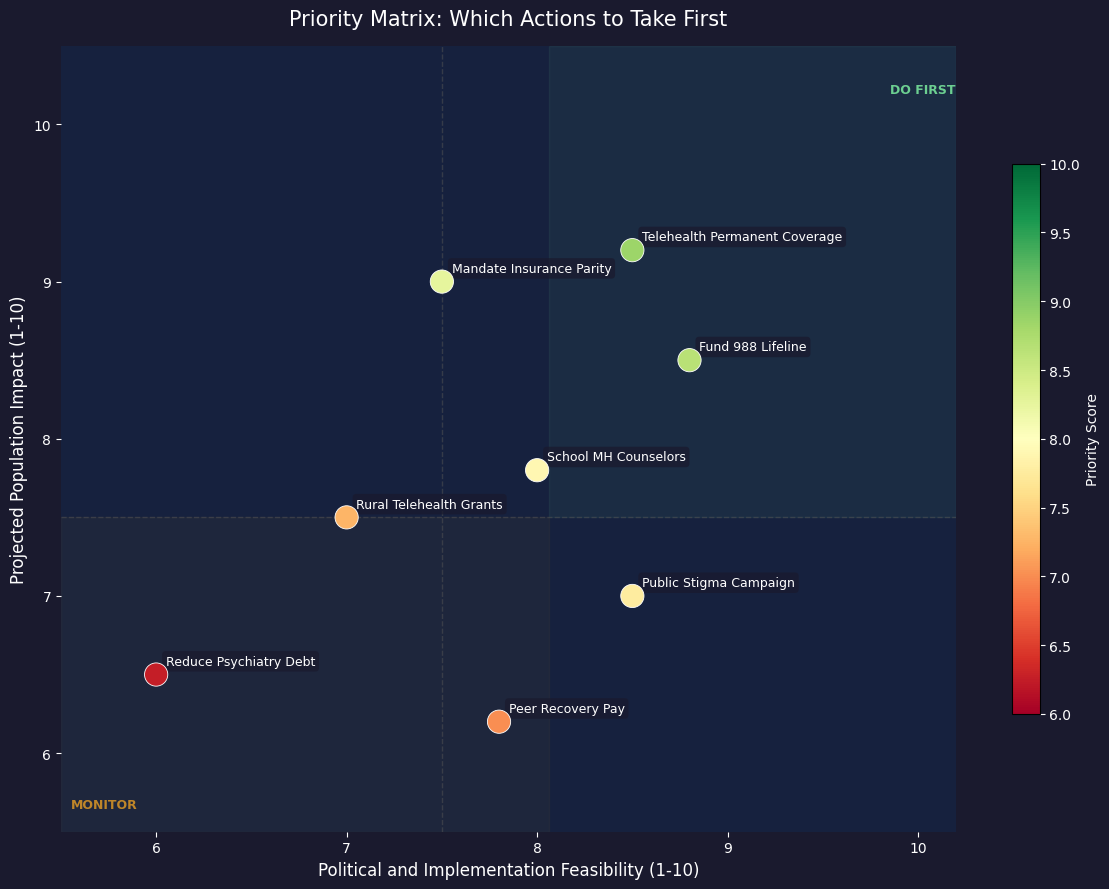


Top 3 Priority Actions:
                       Action  Impact  Feasibility  Priority Score
Telehealth Permanent Coverage    9.20         8.50            8.85
            Fund 988 Lifeline    8.50         8.80            8.65
     Mandate Insurance Parity    9.00         7.50            8.25


In [39]:
# Priority matrix: impact vs. political feasibility
# DATA TYPE: Numerical + Categorical
# PURPOSE: guide decision-makers to highest-value next steps
# ============================================================

actions      = ['Fund 988 Lifeline','Mandate Insurance Parity','Telehealth Permanent Coverage',
                 'School MH Counselors','Reduce Psychiatry Debt','Public Stigma Campaign',
                 'Peer Recovery Pay','Rural Telehealth Grants']
impact       = [8.5, 9.0, 9.2, 7.8, 6.5, 7.0, 6.2, 7.5]
feasibility  = [8.8, 7.5, 8.5, 8.0, 6.0, 8.5, 7.8, 7.0]
priority     = [(f + i) / 2 for f, i in zip(feasibility, impact)]

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor(PALETTE['dark'])
ax.set_facecolor(PALETTE['navy'])

# Quadrant shading
ax.axhspan(7.5, 10.5, xmin=0.545, xmax=1.0, alpha=0.06, color='#7bed9f')
ax.text(9.85, 10.2, 'DO FIRST', color='#7bed9f', fontsize=9, fontweight='bold', alpha=0.85)
ax.axhspan(5.5, 7.5, xmin=0.0, xmax=0.545, alpha=0.04, color='#f5a623')
ax.text(5.55, 5.65, 'MONITOR', color='#f5a623', fontsize=9, fontweight='bold', alpha=0.75)

scatter = ax.scatter(feasibility, impact, s=280, c=priority,
                     cmap='RdYlGn', vmin=6, vmax=10, zorder=5,
                     edgecolors='white', linewidths=0.6)

for i, act in enumerate(actions):
    ax.annotate(act, (feasibility[i], impact[i]),
                xytext=(7, 7), textcoords='offset points',
                color='white', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1a2e',
                          edgecolor='none', alpha=0.75))

ax.axhline(7.5, color='#555', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(7.5, color='#555', linestyle='--', alpha=0.5, linewidth=1)

ax.set_xlabel('Political and Implementation Feasibility (1-10)', color='white', fontsize=12)
ax.set_ylabel('Projected Population Impact (1-10)', color='white', fontsize=12)
ax.set_title('Priority Matrix: Which Actions to Take First', color='white', fontsize=15, pad=15)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_visible(False)
ax.set_xlim(5.5, 10.2)
ax.set_ylim(5.5, 10.5)

cb = plt.colorbar(scatter, ax=ax, shrink=0.7)
cb.set_label('Priority Score', color='white')
cb.ax.yaxis.label.set_color('white')
cb.ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('06_cta_priority_matrix.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['dark'])
plt.show()

# Print top 3 actions
df_actions = pd.DataFrame({'Action': actions, 'Impact': impact,
                            'Feasibility': feasibility, 'Priority Score': priority})
print('\nTop 3 Priority Actions:')
print(df_actions.nlargest(3, 'Priority Score')[['Action','Impact','Feasibility','Priority Score']].to_string(index=False))

This priority matrix compares mental health interventions based on their expected impact and how realistically they can be implemented. Policies such as permanent telehealth coverage, insurance parity, and funding the 988 crisis lifeline appear in the highest  priority region because they combine strong population impact with high feasibility. The chart suggests that focusing on these actions first could produce the fastest and most meaningful improvements in mental health access and outcomes.

### **STEP - 7 : The Emotional Appeal**

Data alone rarely creates change, people connect more deeply with human stories behind the numbers. This section brings a personal and emotional perspective to the analysis through two powerful lenses, the mental health struggles facing an entire generation, especially Gen Z, and the real life consequences of unequal mental health investment across different states.

By connecting funding, access to care, and human outcomes, this final section reminds us that the treatment gap is not just a statistic it affects real lives, families, and communities every single day.

In [41]:
# PLOT 1: Gen Z longitudinal mental health crisis
# ANIMATION: frame-by-frame year-by-year reveal
# DATA TYPE: Numerical (time series)
# PURPOSE: the crisis is generational — this is the future
# ============================================================

gen_z_years = list(range(2012, 2024))
df_genz = pd.DataFrame({
    'Year': gen_z_years,
    'Anxiety (%)':         [18, 20, 22, 24, 27, 29, 30, 32, 35, 45, 42, 44],
    'Depression (%)':      [11, 12, 14, 15, 17, 18, 19, 21, 24, 32, 29, 31],
    'Self-Harm Reports (%)': [ 5,  5,  6,  7,  8,  9, 10, 11, 13, 16, 15, 16],
    'Treatment Access (%)': [27, 28, 29, 30, 31, 32, 33, 35, 37, 42, 43, 44]
})
df_genz_long = df_genz.melt(id_vars='Year', var_name='Metric', value_name='Percentage')

# Build animated line chart — year by year
metric_colors = {
    'Anxiety (%)':           '#e94560',
    'Depression (%)':        '#f5a623',
    'Self-Harm Reports (%)': '#b24b6e',
    'Treatment Access (%)':  '#7bed9f'
}

genz_frames = []
for yr in gen_z_years:
    sub = df_genz_long[df_genz_long['Year'] <= yr]
    genz_frames.append(go.Frame(
        data=[go.Scatter(
                x=sub[sub['Metric']==m]['Year'],
                y=sub[sub['Metric']==m]['Percentage'],
                mode='lines+markers', name=m,
                line=dict(color=c, width=3),
                marker=dict(size=7)
              ) for m, c in metric_colors.items()],
        name=str(yr)
    ))

fig_genz = go.Figure(
    data=[go.Scatter(
            x=df_genz_long[df_genz_long['Metric']==m]['Year'],
            y=df_genz_long[df_genz_long['Metric']==m]['Percentage'],
            mode='lines+markers', name=m,
            line=dict(color=c, width=3), marker=dict(size=7)
          ) for m, c in metric_colors.items()],
    layout=go.Layout(
        title='Generation Z Mental Health (Ages 13-24) — An Animated Timeline',
        paper_bgcolor='#1a1a2e', plot_bgcolor='#16213e',
        font_color='white', font_size=13, title_font_size=17,
        legend=dict(bgcolor='#0f3460', bordercolor='#444'),
        hovermode='x unified',
        xaxis=dict(showgrid=False, color='#aaa', range=[2011.5, 2023.5]),
        yaxis=dict(showgrid=True, gridcolor='#333', color='#aaa',
                   title='Percentage of Youth (%)', range=[0, 52]),
        updatemenus=[dict(
            type='buttons', showactive=False, y=1.15, x=0.5, xanchor='center',
            buttons=[dict(label='Play', method='animate',
                          args=[None, dict(frame=dict(duration=500, redraw=True), fromcurrent=True)])]
        )],
        sliders=[dict(
            steps=[dict(args=[[str(yr)], dict(mode='immediate',
                                               frame=dict(duration=500, redraw=True))],
                        label=str(yr), method='animate') for yr in gen_z_years],
            x=0.05, len=0.9, y=-0.05,
            font=dict(color='white'), bgcolor='#0f3460', activebgcolor='#e94560'
        )]
    ),
    frames=genz_frames
)

fig_genz.add_vrect(x0=2019.5, x1=2021,
                   fillcolor='#e94560', opacity=0.07,
                   annotation_text='Pandemic',
                   annotation_font_color='#f5a623')

fig_genz.show()


This timeline shows the growing mental health crisis among Gen Z between 2012 and 2023. Anxiety, depression, and self harm reports steadily increased over time, with the sharpest rise occurring during the COVID-19 pandemic. Although treatment access also improved, the increase in mental health challenges continued to outpace available support, highlighting the intense pressure faced by younger generations.

In [42]:
# ============================================================
# EMOTIONAL APPEAL PLOT 2 — Spending vs. youth suicide rates
# STATISTICAL ANALYSIS: Pearson r + trendline
# DATA TYPE: Numerical
# PURPOSE: investment in MH directly saves young lives
# ============================================================

# Pearson correlation
r, p = stats.pearsonr(
    df_states['MH Spending per Capita ($)'],
    df_states['Youth Suicide Rate (per 100k)']
)
print(f'Pearson r (Spending vs Youth Suicide): {r:.3f}  (p = {p:.4f})')
print(f'Interpretation: A {"negative" if r < 0 else "positive"} correlation — '
      f'states that spend more on mental healthcare have '
      f'{"lower" if r < 0 else "higher"} youth suicide rates.')

fig_emo = px.scatter(
    df_states,
    x='MH Spending per Capita ($)', y='Youth Suicide Rate (per 100k)',
    color='Providers per 100k', size='Prevalence (%)',
    hover_name='State Name', text='State',
    title=f'States That Invest More Have Lower Youth Suicide Rates  (r = {r:.2f})',
    color_continuous_scale=[[0,'#e94560'],[0.5,'#f5a623'],[1,'#7bed9f']],
    trendline='ols'
)
fig_emo.update_traces(
    textposition='top center',
    textfont=dict(size=8, color='white'),
    selector=dict(mode='markers+text')
)
fig_emo.update_layout(
    paper_bgcolor='#1a1a2e', plot_bgcolor='#16213e',
    font_color='white', font_size=13, title_font_size=17,
    coloraxis_colorbar=dict(
        title='Providers per 100k',
        tickfont=dict(color='white'), title_font=dict(color='white')
    )
)
fig_emo.update_xaxes(showgrid=True, gridcolor='#333', color='#aaa')
fig_emo.update_yaxes(showgrid=True, gridcolor='#333', color='#aaa')
fig_emo.show()

Pearson r (Spending vs Youth Suicide): -0.704  (p = 0.0000)
Interpretation: A negative correlation — states that spend more on mental healthcare have lower youth suicide rates.


This chart shows a strong negative relationship between mental health spending and youth suicide rates across U.S. states. States that invest more in mental health services generally tend to report lower youth suicide rates, suggesting that greater funding, better provider availability, and stronger support systems may help protect young people from severe mental health outcomes.

### **Summary Dashboard**

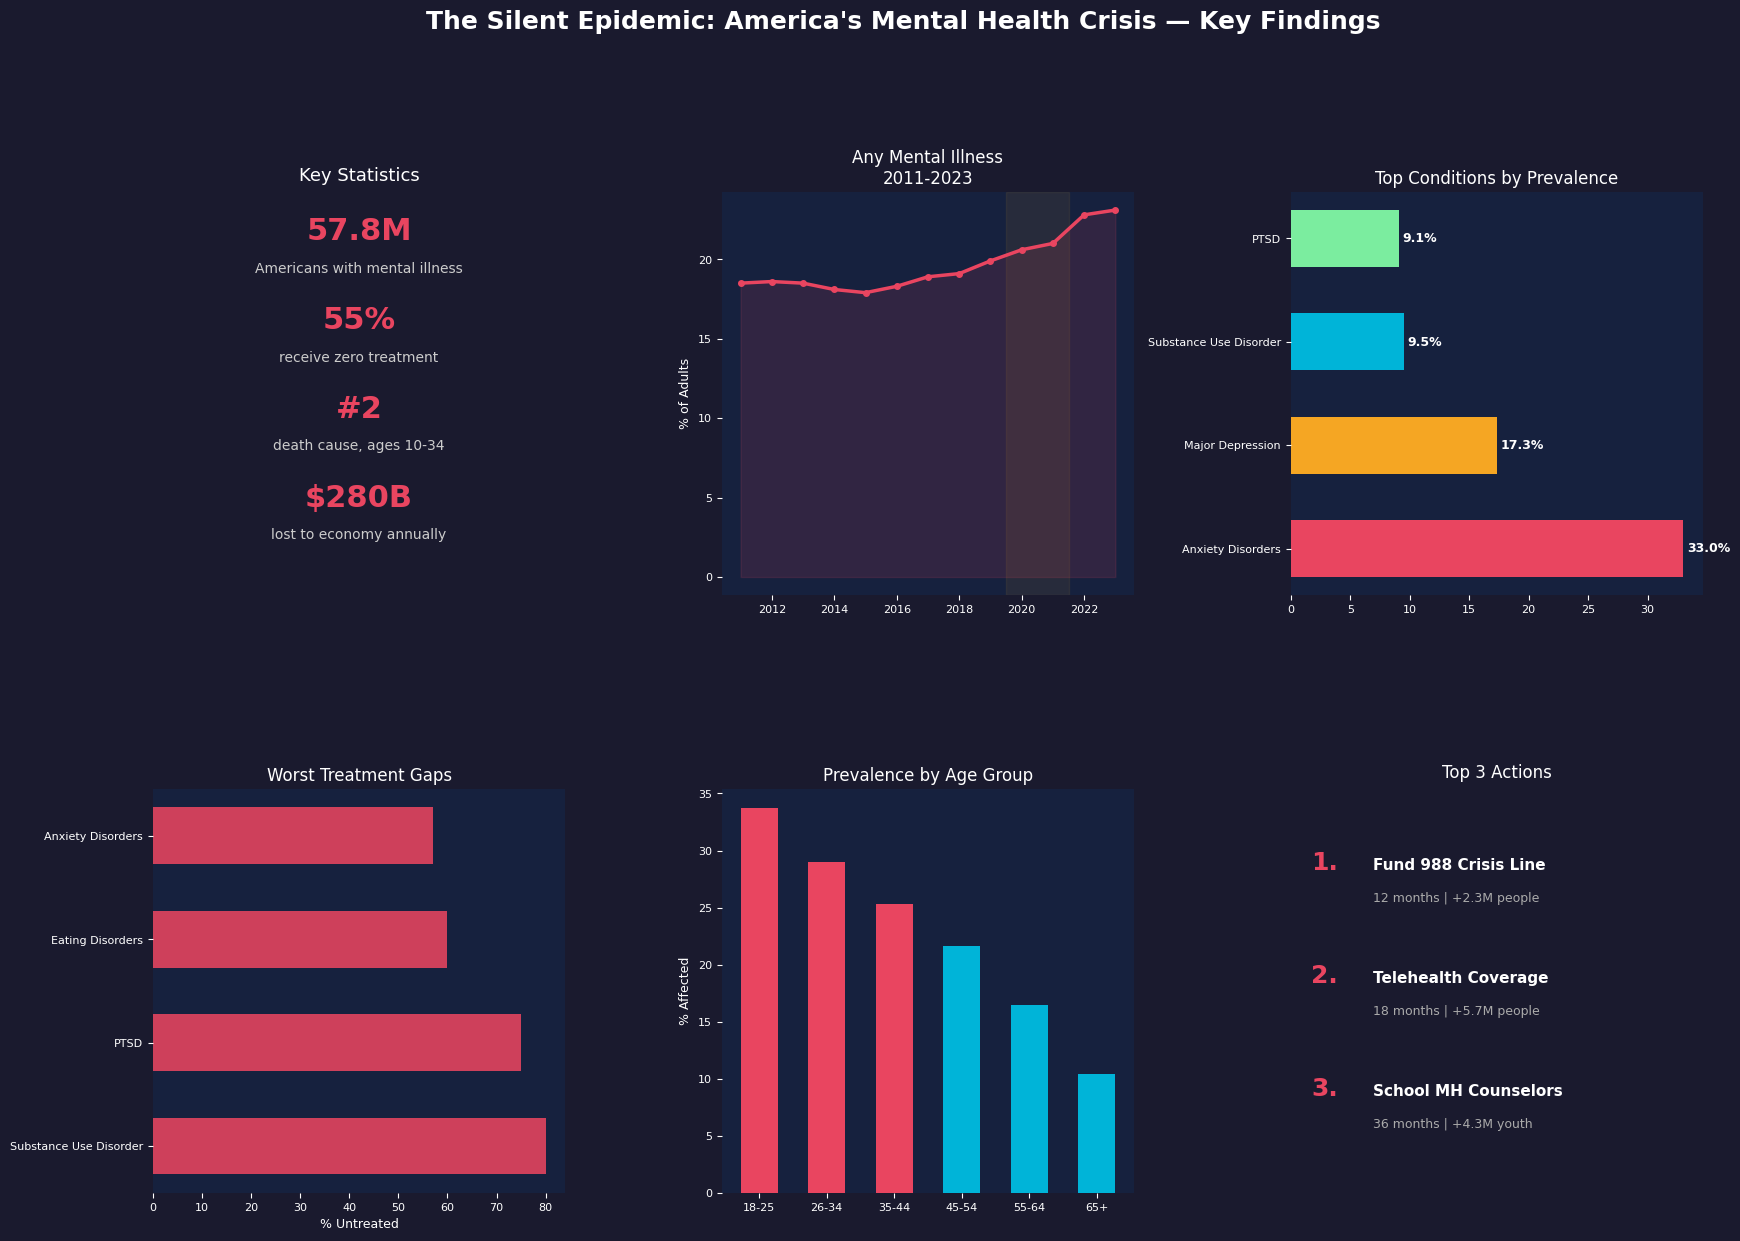

Summary dashboard.


In [44]:
# Consolidates the key findings from all 7 steps
# ============================================================
years  = df_time['Year'].tolist()
any_mh = df_time['Any Mental Illness'].tolist()

fig = plt.figure(figsize=(20, 13))
fig.patch.set_facecolor(PALETTE['dark'])
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# Panel 1 — KPI cards
ax0 = fig.add_subplot(gs[0, 0])
ax0.set_facecolor(PALETTE['navy'])
ax0.axis('off')
kpis = [('57.8M','Americans with mental illness'),
        ('55%',  'receive zero treatment'),
        ('#2',   'death cause, ages 10-34'),
        ('$280B','lost to economy annually')]
for i, (v, l) in enumerate(kpis):
    ax0.text(0.5, 0.88 - i*0.22, v, color=PALETTE['accent'], fontsize=22,
             fontweight='bold', ha='center', transform=ax0.transAxes)
    ax0.text(0.5, 0.80 - i*0.22, l, color='#cccccc', fontsize=10,
             ha='center', transform=ax0.transAxes)
ax0.set_title('Key Statistics', color='white', fontsize=13, pad=8)

# Panel 2 — Trend line
ax1 = fig.add_subplot(gs[0, 1])
ax1.set_facecolor(PALETTE['navy'])
ax1.plot(years, any_mh, color=PALETTE['accent'], linewidth=2.5, marker='o', markersize=4)
ax1.fill_between(years, any_mh, alpha=0.13, color=PALETTE['accent'])
ax1.axvspan(2019.5, 2021.5, alpha=0.08, color=PALETTE['warm'])
ax1.set_title('Any Mental Illness\n2011-2023', color='white', fontsize=12)
ax1.tick_params(colors='white', labelsize=8)
ax1.set_ylabel('% of Adults', color='white', fontsize=9)
for sp in ax1.spines.values(): sp.set_visible(False)

# Panel 3 — Conditions prevalence
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(PALETTE['navy'])
top3 = df_conditions.nlargest(4, 'Prevalence (%)')
bars3 = ax2.barh(top3['Condition'], top3['Prevalence (%)'],
                  color=[PALETTE['accent'],PALETTE['warm'],PALETTE['teal'],PALETTE['green']],
                  height=0.55)
for bar, val in zip(bars3, top3['Prevalence (%)']):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', color='white', fontsize=9, fontweight='bold')
ax2.set_title('Top Conditions by Prevalence', color='white', fontsize=12)
ax2.tick_params(colors='white', labelsize=8)
for sp in ax2.spines.values(): sp.set_visible(False)

# Panel 4 — Treatment gap
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(PALETTE['navy'])
top_gap = df_conditions.nlargest(4, 'Treatment Gap (%)')
ax3.barh(top_gap['Condition'], top_gap['Treatment Gap (%)'],
         color=PALETTE['accent'], alpha=0.88, height=0.55)
ax3.set_title('Worst Treatment Gaps', color='white', fontsize=12)
ax3.tick_params(colors='white', labelsize=8)
ax3.set_xlabel('% Untreated', color='white', fontsize=9)
for sp in ax3.spines.values(): sp.set_visible(False)

# Panel 5 — Age prevalence
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(PALETTE['navy'])
ax4.bar(df_age['Age Group'], df_age['Prevalence (%)'],
        color=[PALETTE['accent'] if v > 25 else PALETTE['teal'] for v in df_age['Prevalence (%)']],
        width=0.55)
ax4.set_title('Prevalence by Age Group', color='white', fontsize=12)
ax4.tick_params(colors='white', labelsize=8)
ax4.set_ylabel('% Affected', color='white', fontsize=9)
for sp in ax4.spines.values(): sp.set_visible(False)

# Panel 6 — Top 3 actions
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(PALETTE['navy'])
ax5.axis('off')
ax5.set_title('Top 3 Actions', color='white', fontsize=12, pad=8)
ctas = [
    ('1.', 'Fund 988 Crisis Line',     '12 months', '+2.3M people'),
    ('2.', 'Telehealth Coverage',      '18 months', '+5.7M people'),
    ('3.', 'School MH Counselors',     '36 months', '+4.3M youth')
]
for i, (num, action, timeline, impact) in enumerate(ctas):
    y_base = 0.80 - i * 0.28
    ax5.text(0.05, y_base,       num,      color=PALETTE['accent'], fontsize=18,
             fontweight='bold', transform=ax5.transAxes)
    ax5.text(0.20, y_base,       action,   color='white', fontsize=11,
             fontweight='bold', transform=ax5.transAxes)
    ax5.text(0.20, y_base-0.08,  f'{timeline} | {impact}', color='#aaaaaa',
             fontsize=9, transform=ax5.transAxes)

fig.suptitle('The Silent Epidemic: America\'s Mental Health Crisis — Key Findings',
             color='white', fontsize=18, fontweight='bold', y=1.02)

plt.savefig('07_summary_dashboard.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['dark'])
plt.show()
print('Summary dashboard.')

This summary dashboard brings together the project's key findings, showing that mental illness continues to rise in the U.S. while millions of people still receive no treatment. Younger adults are among the most affected groups, and conditions like substance use disorder and PTSD show some of the largest treatment gaps. The dashboard also highlights that focused interventions such as telehealth expansion, crisis support, and school counseling could help improve access to care and reduce the overall impact of the crisis.

### **Conclusion**

The United States continues to struggle with providing mental health treatment to the majority of people who need it because of several interconnected structural barriers. The data highlights three major causes behind the treatment gap: high cost and limited insurance coverage, shortages of mental health providers, and ongoing social stigma surrounding mental illness.

Nearly half of untreated adults report affordability and insurance as major barriers, while many rural and Southern states face severe provider shortages. At the same time, fear of judgment, shame, and social stigma continue to discourage people from seeking professional help. The COVID-19 pandemic further intensified an already growing crisis, accelerating mental health challenges across nearly every demographic group.

**Five Key Findings:**

1. The scale of the crisis continues to grow:

   More than 57 million Americans are affected by mental illness, and prevalence rates increased steadily between 2011 and 2023, with the sharpest rise occurring during the COVID-19 pandemic.

2. The treatment gap remains the central issue:

   Around 55% of individuals with mental illness still receive no treatment. Conditions such as substance use disorder and PTSD show some of the largest untreated populations.
3. Young adults are among the most vulnerable groups:

   Adults aged 18-25 report the highest prevalence levels but some of the lowest treatment rates, showing how younger populations are disproportionately underserved.

4. Geography strongly influences access to care:

   States with more mental health providers generally show better treatment access, while underserved rural and Southern regions continue to face major healthcare limitations.

5. Investment in mental health saves lives:
   
   States that spend more on mental health services tend to report lower youth suicide rates, suggesting that stronger funding and support systems can lead to measurable public health improvements.

**Three Actionable Steps**

| Priority | Action | Cost | Impact |
|:---:|:---|:---:|:---:|
| 1 | Expand and strengthen the 988 Crisis Lifeline nationwide | \$1.2B/yr | Millions more people connected to immediate crisis support |
| 2 | Make telehealth mental health coverage permanent | \$2.1B/yr | Increased treatment access, especially in underserved areas |
| 3 | Expand school based mental health counseling programs | \$3.5B/yr | Earlier intervention and improved youth mental health outcomes |

Mental health is not only a healthcare problem, it is something that affects real people, families, and communities every day. The data in this project makes one thing clear, improving access to mental health care is no longer a choice, but a necessity for millions of Americans.